In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
# Add these imports at the top if not already present
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')


# # =============================================================================
# # CONFIGURATION CONSTANTS
# # =============================================================================
# MIN_YEARS_ACTIVE = 0.01  # Avoid division by zero
# RECENT_ACTIVITY_DAYS = 180  # 6 months
# HOLIDAY_MONTHS = [11, 12]  # November, December
# SUMMER_MONTHS = [6, 7, 8]  # June, July, August
# FRIDAY_DAY = 4  # 0=Monday, 4=Friday
# TOP_N_THRESHOLD = 50  # Top 50 for hit rate calculation

In [248]:
# Load the ML-ready dataset
df = pd.read_csv('ml_ready_with_features.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9161, 19)

Column names:
['id', 'Title', 'Artists', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', '# of Nationality', 'Loudness_norm', 'best_rank', 'weeks_on_chart', 'peak_score', 'longevity_score', 'popularity_score', 'popularity_label']

First few rows:


,id,Title,Artists,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,# of Nationality,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score,popularity_label
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,0.748,0.627,-6.029,0.064,0.131,0.0,0.524,Artist 1,Nationality 1,0.825120,40,118,80.5,100.0,80.25,Popular
1,003VDDA7J3Xb2ZFlNx7nIZ,YELL OH,"Trippie Redd, Young Thug",0.842,0.578,-6.050,0.138,0.004,0.0,0.190,Artist 1,Nationality 1,0.824511,108,2,46.5,10.0,27.25,Not Popular
2,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,-6.276,0.733,0.082,0.0,0.437,Artist 1,Nationality 1,0.817955,91,14,55.0,70.0,55.50,Not Popular
3,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0.352,0.911,-5.230,0.075,0.001,0.0,0.236,Artist 1,Nationality 1,0.848296,73,560,64.0,100.0,72.00,Popular
4,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),Cardi B,0.620,0.625,-7.438,0.553,0.287,0.0,0.665,Artist 1,Nationality 1,0.784249,61,14,70.0,70.0,63.00,Not Popular


In [249]:
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


# Basic statistics
print(f"\nFeature statistics:")
df.describe()

Missing values:
id                  0
Title               0
Artists             0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Valence             0
# of Artist         0
# of Nationality    0
Loudness_norm       0
best_rank           0
weeks_on_chart      0
peak_score          0
longevity_score     0
popularity_score    0
popularity_label    0
dtype: int64

Feature statistics:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,best_rank,weeks_on_chart,peak_score,longevity_score,popularity_score
count,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.000000,9161.00000,9161.000000,9161.000000
mean,0.674146,0.636076,-6.465501,0.128299,0.234024,0.013770,0.486465,0.812458,87.258160,50.983626,56.87092,51.429975,49.007450
std,0.147904,0.170402,2.641113,0.117881,0.248563,0.082544,0.226281,0.076610,58.544799,120.342609,29.27240,41.295436,28.067511
min,0.073000,0.005000,-34.475000,0.022000,0.000000,0.000000,0.026000,0.000000,1.000000,1.000000,0.50000,5.000000,2.250000
25%,0.581000,0.532000,-7.638000,0.044000,0.040000,0.000000,0.310000,0.778448,35.000000,2.000000,33.00000,10.000000,23.000000
50%,0.691000,0.651000,-6.063000,0.076000,0.139000,0.000000,0.482000,0.824133,81.000000,8.000000,60.00000,40.000000,49.750000
75%,0.782000,0.761000,-4.731000,0.180000,0.351000,0.000000,0.660000,0.862770,135.000000,44.000000,83.00000,100.000000,75.750000
max,0.985000,0.996000,0.000000,0.966000,0.994000,0.956000,0.982000,1.000000,200.000000,2251.000000,100.00000,100.000000,90.000000


In [250]:
# Check label distribution - cleaner output
print(f"\n{'='*50}")
print("LABEL DISTRIBUTION")
print('='*50)

# Counts
print("\nCounts:")
for label, count in df['popularity_label'].value_counts().items():
    print(f"  {label:15s}: {count:,}")

# Percentages
print("\nPercentages:")
for label, pct in (df['popularity_label'].value_counts(normalize=True) * 100).items():
    print(f"  {label:15s}: {pct:.2f}%")

print(f"\nTotal songs: {len(df):,}")
print('='*50)


LABEL DISTRIBUTION

Counts:
  Not Popular    : 6,391
  Popular        : 2,770

Percentages:
  Not Popular    : 69.76%
  Popular        : 30.24%

Total songs: 9,161


In [251]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Check column names first
print("Columns in df_charts:")
print(df_charts.columns.tolist())
print("\nFirst few rows:")
print(df_charts.head())

Columns in df_charts:
['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality', 'Nationality', 'Continent', 'Points (Total)', 'Points (Ind for each Artist/Nat)', 'id', 'Song URL', 'Loudness_norm']

First few rows:
   Rank              Title                     Artists       Date  \
0     1    Ella Baila Sola  Eslabon Armado, Peso Pluma 2023-05-29   
1     2     WHERE SHE GOES                   Bad Bunny 2023-05-29   
2     3    La Bebe - Remix       Yng Lvcas, Peso Pluma 2023-05-29   
3     4  Cupid - Twin Ver.                 FIFTY FIFTY 2023-05-29   
4     5          un x100to   Grupo Frontera, Bad Bunny 2023-05-29   

   Danceability  Energy  Loudness  Speechiness  Acousticness  \
0         0.668   0.758    -5.176        0.033         0.483   
1         0.652   0.800    -4.019        0.061         0.143   
2         0.812   0.479    -5.678        0.333  

In [252]:
# Load original chart data to calculate artist features
df_charts = pd.read_csv('final_cleaned_data.csv', delimiter=';')
df_charts['Date'] = pd.to_datetime(df_charts['Date'])

# Calculate artist features from ENTIRE chart history
artist_features = df_charts.groupby('Artist (Ind.)').agg({
    'Rank': ['mean', 'min', 'count'],
    'Date': ['min', 'max'],
    'Title': 'nunique'
}).reset_index()

# Flatten multi-level column names
artist_features.columns = ['_'.join(col).strip('_') for col in artist_features.columns.values]

# Rename to cleaner names
artist_features.columns = ['artist', 'avg_rank', 'best_rank', 'total_appearances',
                           'first_appearance', 'last_appearance', 'unique_songs']

# Calculate derived features
artist_features['years_active'] = (
    (artist_features['last_appearance'] - artist_features['first_appearance']).dt.days / 365
).replace(0, MIN_YEARS_ACTIVE)  # Use constant instead of hardcoded value

artist_features['songs_per_year'] = (
    artist_features['unique_songs'] / artist_features['years_active']
)

artist_features['avg_rank_score'] = (201 - artist_features['avg_rank']) / 200

# Hit rate: What % of artist's songs reached top 50?
print("\n🔍 CALCULATING HIT RATE...")

# Count top 50 songs per artist
top50_songs = df_charts[df_charts['Rank'] <= TOP_N_THRESHOLD].groupby('Artist (Ind.)')['Title'].nunique().reset_index()
top50_songs.columns = ['artist', 'top50_count']

print(f"✓ Artists with top 50 songs: {len(top50_songs)}")
print(f"  Sample:")
print(top50_songs.head())

# Merge with artist_features
artist_features = artist_features.merge(top50_songs, on='artist', how='left')
artist_features['top50_count'] = artist_features['top50_count'].fillna(0)

# Calculate hit_rate
artist_features['hit_rate'] = artist_features['top50_count'] / artist_features['unique_songs']
artist_features['hit_rate'] = artist_features['hit_rate'].fillna(0)

# Verify calculation
print(f"\n✓ HIT RATE STATISTICS:")
print(artist_features['hit_rate'].describe())
print(f"  Artists with hit_rate > 0: {(artist_features['hit_rate'] > 0).sum()}")

# Is the artist currently active?
latest_date = df_charts['Date'].max()
artist_features['is_recently_active'] = (
    (latest_date - artist_features['last_appearance']).dt.days < RECENT_ACTIVITY_DAYS
).astype(int)

print("\n✓ Artist features created!")
print(f"Total artists: {len(artist_features)}")
print(f"\nTop 10 artists by hit_rate:")
print(artist_features.nlargest(10, 'hit_rate')[['artist', 'hit_rate', 'unique_songs', 'top50_count', 'total_appearances']])

# Add this diagnostic after Cell 6
# Cell 6 - Simple version (at the end)
print("\n🔍 TEMPORAL LEAKAGE CHECK:")
print(f"Chart data range: {df_charts['Date'].min()} to {df_charts['Date'].max()}")
print(f"Chart span: {(df_charts['Date'].max() - df_charts['Date'].min()).days} days")

# Verify no future leakage
# Replace with this simple version:
print("\n🔍 TEMPORAL LEAKAGE CHECK:")
print(f"Chart data range: {df_charts['Date'].min()} to {df_charts['Date'].max()}")
print(f"Chart span: {(df_charts['Date'].max() - df_charts['Date'].min()).days} days")
print("\n✓ Artist features calculated from entire chart history")
print("   (Detailed temporal validation will run after Cell 10)")


🔍 CALCULATING HIT RATE...
✓ Artists with top 50 songs: 583
  Sample:
                artist  top50_count
0             2 Chainz            1
1            21 Savage           15
2             24kGoldn            2
3  5 Seconds of Summer            4
4              50 Cent            1

✓ HIT RATE STATISTICS:
count    1507.000000
mean        0.212916
std         0.335170
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: hit_rate, dtype: float64
  Artists with hit_rate > 0: 583

✓ Artist features created!
Total artists: 1507

Top 10 artists by hit_rate:
            artist  hit_rate  unique_songs  top50_count  total_appearances
14         50 Cent       1.0             1          1.0                 73
26          ACRAZE       1.0             1          1.0                281
31             ATB       1.0             1          1.0                241
32          AURORA       1.0             1          1.0                144
42    

In [253]:
# For multi-artist songs, we'll use the LEAD artist's features
# Extract first artist from the Artists column
df['lead_artist'] = (
    df['Artists']
    .str.replace('&', ',')
    .str.replace(' Featuring ', ',', case=False)
    .str.split(',')
    .str[0]
    .str.strip()
)

# Merge artist features
df_enhanced = df.merge(
    artist_features[['artist', 'avg_rank_score', 'hit_rate', 'years_active', 
                     'songs_per_year', 'is_recently_active', 'total_appearances']],
    left_on='lead_artist',
    right_on='artist',
    how='left'
)

# Fill missing values with median (for new/unknown artists)
artist_cols = ['avg_rank_score', 'hit_rate', 'years_active', 
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nNew artist features added: {artist_cols}")

# Verify hit_rate after merge
print(f"\n✓ HIT_RATE IN ENHANCED DATASET:")
print(f"  Mean: {df_enhanced['hit_rate'].mean():.4f}")
print(f"  Non-zero: {(df_enhanced['hit_rate'] > 0).sum()} ({(df_enhanced['hit_rate'] > 0).sum()/len(df_enhanced)*100:.2f}%)")

# Add after Cell 7's merge
print(f"\n🔍 MERGE VALIDATION:")
print(f"Songs before merge: {len(df)}")
print(f"Songs after merge:  {len(df_enhanced)}")
print(f"Unmatched artists:  {df_enhanced['artist'].isna().sum()}")

# Show sample of unmatched
if df_enhanced['artist'].isna().any():
    print("\nSample unmatched lead artists:")
    print(df[df_enhanced['artist'].isna()]['lead_artist'].value_counts().head(10))

Enhanced dataset shape: (9161, 27)

New artist features added: ['avg_rank_score', 'hit_rate', 'years_active', 'songs_per_year', 'is_recently_active', 'total_appearances']

✓ HIT_RATE IN ENHANCED DATASET:
  Mean: 0.3405
  Non-zero: 7332 (80.03%)

🔍 MERGE VALIDATION:
Songs before merge: 9161
Songs after merge:  9161
Unmatched artists:  171

Sample unmatched lead artists:
lead_artist
Tyler           50
Zé Neto         11
Henrique         8
Jorge            8
Lil s X          6
French Monta     6
Guilherme        5
Israel           5
C. Tangana       5
Hugo             4
Name: count, dtype: int64


In [254]:
# Create engineered features - Audio Interactions on the ENHANCED dataframe
df_enhanced['dance_potential'] = df_enhanced['Energy'] * df_enhanced['Danceability']
df_enhanced['feel_good_score'] = df_enhanced['Valence'] * df_enhanced['Energy']
df_enhanced['chill_score'] = df_enhanced['Acousticness'] * (1 - df_enhanced['Energy'])
df_enhanced['party_score'] = 0.4 * df_enhanced['Energy'] + 0.4 * df_enhanced['Danceability'] + 0.2 * df_enhanced['Valence']

print("✓ Audio interaction features created successfully!")
print(f"\nNew features preview:")
print(df_enhanced[['dance_potential', 'feel_good_score', 'chill_score', 'party_score']].describe())

✓ Audio interaction features created successfully!

New features preview:
       dance_potential  feel_good_score  chill_score  party_score
count      9161.000000      9161.000000  9161.000000  9161.000000
mean          0.432021         0.323782     0.107706     0.621382
std           0.146726         0.190431     0.161570     0.123604
min           0.001022         0.000518     0.000000     0.042200
25%           0.341044         0.172032     0.010669     0.551800
50%           0.443275         0.302286     0.041184     0.635600
75%           0.535806         0.455112     0.124683     0.708800
max           0.870610         0.939910     0.965294     0.928000


In [255]:
# ============================================
# TEMPORAL FEATURES
# ============================================

# For each song, get first appearance date from chart data
song_first_date = df_charts.groupby('Title')['Date'].min().reset_index()
song_first_date.columns = ['Title', 'release_date']

# Extract temporal features
song_first_date['release_month'] = song_first_date['release_date'].dt.month
song_first_date['release_quarter'] = song_first_date['release_date'].dt.quarter
song_first_date['release_year'] = song_first_date['release_date'].dt.year
song_first_date['release_day_of_week'] = song_first_date['release_date'].dt.dayofweek

# Strategic release timing
song_first_date['is_holiday_season'] = (
    song_first_date['release_month'].isin([11, 12])
).astype(int)

song_first_date['is_summer'] = (
    song_first_date['release_month'].isin([6, 7, 8])
).astype(int)

song_first_date['is_friday_release'] = (
    song_first_date['release_day_of_week'] == 4
).astype(int)

# Days since release
latest_date = df_charts['Date'].max()
song_first_date['days_since_release'] = (
    (latest_date - song_first_date['release_date']).dt.days
)

print("✓ Temporal features created!")
print(f"Total songs with temporal data: {len(song_first_date)}")
print(f"\nTemporal features preview:")
print(song_first_date[['Title', 'release_month', 'is_holiday_season', 
                        'is_summer', 'is_friday_release', 'days_since_release']].head(10))

✓ Temporal features created!
Total songs with temporal data: 7440

Temporal features preview:
                                                          Title  \
0                                                    '98 Braves   
1                                                             !   
2                                           #PROUDCATOWNERREMIX   
3                                                           $$$   
4                                                  $€ Freestyle   
5                                              'Till I Collapse   
6                                          'tis the damn season   
7                                       (Don't Fear) The Reaper   
8                                        (Fuck A) Silver Lining   
9  (There's No Place Like) Home for the Holidays - 1959 Version   

   release_month  is_holiday_season  is_summer  is_friday_release  \
0              3                  0          0                  1   
1              8              

In [256]:
# Merge temporal features with enhanced dataset
df_enhanced = df_enhanced.merge(
    song_first_date[['Title', 'release_month', 'release_quarter', 'is_holiday_season',
                     'is_summer', 'is_friday_release', 'days_since_release']],
    on='Title',
    how='left',
    validate='many_to_one'  # ✓ Check for duplicates
)

# Fill missing values
temporal_cols = ['release_month', 'release_quarter', 'is_holiday_season',
                 'is_summer', 'is_friday_release', 'days_since_release']

for col in temporal_cols:
    if col in ['is_holiday_season', 'is_summer', 'is_friday_release']:
        df_enhanced[col] = df_enhanced[col].fillna(0).astype(int)
    else:
        df_enhanced[col] = df_enhanced[col].fillna(df_enhanced[col].median())

print(f"✓ Temporal features merged!")
print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"\nMissing values check:")
print(df_enhanced[temporal_cols].isnull().sum())

# DIAGNOSE merge success
print(f"\n🔍 MERGE DIAGNOSTIC:")
print(f"   Songs in df_enhanced: {len(df_enhanced)}")
print(f"   Unique songs in song_first_date: {len(song_first_date)}")
print(f"   Holiday season songs: {(df_enhanced['is_holiday_season'] == 1).sum()}")
print(f"   Summer songs: {(df_enhanced['is_summer'] == 1).sum()}")
print(f"   Friday releases: {(df_enhanced['is_friday_release'] == 1).sum()}")

✓ Temporal features merged!
Enhanced dataset shape: (9161, 37)

Missing values check:
release_month         0
release_quarter       0
is_holiday_season     0
is_summer             0
is_friday_release     0
days_since_release    0
dtype: int64

🔍 MERGE DIAGNOSTIC:
   Songs in df_enhanced: 9161
   Unique songs in song_first_date: 7440
   Holiday season songs: 1534
   Summer songs: 2141
   Friday releases: 5911


In [257]:
# Verify temporal features distribution
print("\n" + "="*60)
print("TEMPORAL FEATURES DISTRIBUTION")
print("="*60)

print(f"\nRelease Month:")
print(df_enhanced['release_month'].value_counts().sort_index())

print(f"\nHoliday Season Releases: {df_enhanced['is_holiday_season'].sum()} ({df_enhanced['is_holiday_season'].mean()*100:.1f}%)")
print(f"Summer Releases: {df_enhanced['is_summer'].sum()} ({df_enhanced['is_summer'].mean()*100:.1f}%)")
print(f"Friday Releases: {df_enhanced['is_friday_release'].sum()} ({df_enhanced['is_friday_release'].mean()*100:.1f}%)")

print(f"\nDays Since Release:")
print(df_enhanced['days_since_release'].describe())


TEMPORAL FEATURES DISTRIBUTION

Release Month:
release_month
1     975
2     695
3     826
4     731
5     921
6     683
7     730
8     728
9     643
10    695
11    724
12    810
Name: count, dtype: int64

Holiday Season Releases: 1534 (16.7%)
Summer Releases: 2141 (23.4%)
Friday Releases: 5911 (64.5%)

Days Since Release:
count    9161.000000
mean     1282.414693
std       664.848198
min         1.000000
25%       722.000000
50%      1309.000000
75%      1856.000000
max      2339.000000
Name: days_since_release, dtype: float64


In [258]:
# =============================================================================
# COMPREHENSIVE DIAGNOSTIC: ARTIST + TEMPORAL FEATURES
# =============================================================================

# # Add this at the START of Cell 12 (before PART 5):
# from sklearn.preprocessing import LabelEncoder
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(df_enhanced['popularity_label'])
# print("="*80)
# print("🔍 COMPREHENSIVE FEATURE DIAGNOSTIC")
# print("="*80)

# ============================================
# PART 1: ARTIST FEATURES DIAGNOSTIC
# ============================================
print("\n" + "="*80)
print("📊 PART 1: ARTIST FEATURES")
print("="*80)

artist_cols = ['avg_rank_score', 'hit_rate', 'years_active', 
               'songs_per_year', 'is_recently_active', 'total_appearances']

for col in artist_cols:
    print(f"\n{'─'*80}")
    print(f"🎤 {col.upper()}")
    print('─'*80)
    
    # Check if column exists
    if col not in df_enhanced.columns:
        print(f"❌ Column '{col}' NOT FOUND in df_enhanced!")
        continue
    
    # Basic stats
    print(f"✓ Column exists")
    print(f"  Mean:        {df_enhanced[col].mean():.4f}")
    print(f"  Median:      {df_enhanced[col].median():.4f}")
    print(f"  Min:         {df_enhanced[col].min():.4f}")
    print(f"  Max:         {df_enhanced[col].max():.4f}")
    print(f"  Std:         {df_enhanced[col].std():.4f}")
    print(f"  Missing:     {df_enhanced[col].isna().sum()} ({df_enhanced[col].isna().sum()/len(df_enhanced)*100:.2f}%)")
    print(f"  Zeros:       {(df_enhanced[col] == 0).sum()} ({(df_enhanced[col] == 0).sum()/len(df_enhanced)*100:.2f}%)")
    
    # Check for suspicious values
    if col == 'hit_rate':
        print(f"  Non-zero:    {(df_enhanced[col] > 0).sum()} ({(df_enhanced[col] > 0).sum()/len(df_enhanced)*100:.2f}%)")
        if (df_enhanced[col] == 0).all():
            print("  ⚠️  WARNING: ALL ZEROS!")
    
    # Value distribution (for binary features)
    if col == 'is_recently_active':
        print(f"\n  Value distribution:")
        print(df_enhanced[col].value_counts().to_string())

# Top 10 songs by each artist feature
print(f"\n{'='*80}")
print("🏆 TOP 10 SONGS BY ARTIST FEATURES")
print('='*80)

for col in ['avg_rank_score', 'hit_rate', 'total_appearances']:
    print(f"\n📌 Top 10 by {col}:")
    print(df_enhanced.nlargest(10, col)[['Title', 'Artists', col]].to_string(index=False))

# ============================================
# PART 2: TEMPORAL FEATURES DIAGNOSTIC
# ============================================
print("\n\n" + "="*80)
print("📅 PART 2: TEMPORAL FEATURES")
print("="*80)

temporal_cols = ['release_month', 'release_quarter', 'is_holiday_season',
                 'is_summer', 'is_friday_release', 'days_since_release']

for col in temporal_cols:
    print(f"\n{'─'*80}")
    print(f"🗓️  {col.upper()}")
    print('─'*80)
    
    # Check if column exists
    if col not in df_enhanced.columns:
        print(f"❌ Column '{col}' NOT FOUND in df_enhanced!")
        continue
    
    # Basic stats
    print(f"✓ Column exists")
    print(f"  Mean:        {df_enhanced[col].mean():.4f}")
    print(f"  Median:      {df_enhanced[col].median():.4f}")
    print(f"  Min:         {df_enhanced[col].min():.4f}")
    print(f"  Max:         {df_enhanced[col].max():.4f}")
    print(f"  Missing:     {df_enhanced[col].isna().sum()} ({df_enhanced[col].isna().sum()/len(df_enhanced)*100:.2f}%)")
    print(f"  Zeros:       {(df_enhanced[col] == 0).sum()} ({(df_enhanced[col] == 0).sum()/len(df_enhanced)*100:.2f}%)")
    
    # Binary features
    if col in ['is_holiday_season', 'is_summer', 'is_friday_release']:
        print(f"  Non-zero:    {(df_enhanced[col] == 1).sum()} ({(df_enhanced[col] == 1).sum()/len(df_enhanced)*100:.2f}%)")
        if (df_enhanced[col] == 0).all():
            print(f"  ⚠️  WARNING: ALL ZEROS!")
        print(f"\n  Value distribution:")
        print(df_enhanced[col].value_counts().to_string())
    
    # Continuous features
    if col in ['release_month', 'release_quarter']:
        print(f"\n  Value distribution:")
        print(df_enhanced[col].value_counts().sort_index().to_string())

# Sample temporal data
print(f"\n{'='*80}")
print("📋 SAMPLE TEMPORAL DATA (10 random songs)")
print('='*80)
print(df_enhanced[['Title', 'Artists'] + temporal_cols].sample(10).to_string(index=False))

# ============================================
# PART 3: MERGE SUCCESS VERIFICATION
# ============================================
print("\n\n" + "="*80)
print("🔗 PART 3: MERGE SUCCESS VERIFICATION")
print("="*80)

print(f"\n📊 Dataset Sizes:")
print(f"  df_enhanced:        {len(df_enhanced):,} songs")
print(f"  song_first_date:    {len(song_first_date):,} unique songs")
print(f"  artist_features:    {len(artist_features):,} artists")

print(f"\n🔍 Merge Quality (Temporal):")
print(f"  Songs with temporal data:  {df_enhanced['release_month'].notna().sum():,} ({df_enhanced['release_month'].notna().sum()/len(df_enhanced)*100:.2f}%)")
print(f"  Holiday releases:          {df_enhanced['is_holiday_season'].sum():,}")
print(f"  Summer releases:           {df_enhanced['is_summer'].sum():,}")
print(f"  Friday releases:           {df_enhanced['is_friday_release'].sum():,}")

print(f"\n🔍 Merge Quality (Artist):")
print(f"  Songs with artist data:    {df_enhanced['hit_rate'].notna().sum():,} ({df_enhanced['hit_rate'].notna().sum()/len(df_enhanced)*100:.2f}%)")
print(f"  Recently active artists:   {df_enhanced['is_recently_active'].sum():,}")

# ============================================
# PART 4: POTENTIAL ISSUES
# ============================================
print("\n\n" + "="*80)
print("⚠️  PART 4: POTENTIAL ISSUES")
print("="*80)

issues = []

# Check all zeros
for col in artist_cols + temporal_cols:
    if col in df_enhanced.columns:
        if (df_enhanced[col] == 0).all():
            issues.append(f"❌ {col}: ALL ZEROS")

# Check high missing rate
for col in artist_cols + temporal_cols:
    if col in df_enhanced.columns:
        missing_pct = df_enhanced[col].isna().sum() / len(df_enhanced) * 100
        if missing_pct > 10:
            issues.append(f"⚠️  {col}: {missing_pct:.2f}% missing values")

# Check unrealistic values
if 'hit_rate' in df_enhanced.columns:
    if (df_enhanced['hit_rate'] > 1).any():
        issues.append(f"⚠️  hit_rate: Values > 1 detected (should be 0-1)")

if 'release_month' in df_enhanced.columns:
    if (df_enhanced['release_month'] < 1).any() or (df_enhanced['release_month'] > 12).any():
        issues.append(f"⚠️  release_month: Invalid values detected (should be 1-12)")

if issues:
    print("\n🚨 ISSUES DETECTED:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n✅ NO ISSUES DETECTED - All features look good!")

# ============================================
# PART 5: FEATURE CORRELATIONS
# ============================================
print("\n\n" + "="*80)
print("📈 PART 5: FEATURE CORRELATIONS WITH TARGET")
print("="*80)

from scipy.stats import pointbiserialr

all_features = artist_cols + temporal_cols
correlations = []

for col in all_features:
    if col in df_enhanced.columns:
        corr, p_value = pointbiserialr(y_encoded, df_enhanced[col])
        correlations.append({
            'Feature': col,
            'Correlation': corr,
            'Abs_Correlation': abs(corr),
            'P-value': p_value,
            'Significant': '✓' if p_value < 0.05 else '✗'
        })

corr_df = pd.DataFrame(correlations).sort_values('Abs_Correlation', ascending=False)

print("\n🎯 Top 10 Most Correlated Features:")
print(corr_df.head(10)[['Feature', 'Correlation', 'P-value', 'Significant']].to_string(index=False))

print("\n" + "="*80)
print("✅ DIAGNOSTIC COMPLETE!")
print("="*80)


📊 PART 1: ARTIST FEATURES

────────────────────────────────────────────────────────────────────────────────
🎤 AVG_RANK_SCORE
────────────────────────────────────────────────────────────────────────────────
✓ Column exists
  Mean:        0.4479
  Median:      0.4833
  Min:         0.0050
  Max:         0.8942
  Std:         0.1344
  Missing:     0 (0.00%)
  Zeros:       0 (0.00%)

────────────────────────────────────────────────────────────────────────────────
🎤 HIT_RATE
────────────────────────────────────────────────────────────────────────────────
✓ Column exists
  Mean:        0.3405
  Median:      0.2941
  Min:         0.0000
  Max:         1.0000
  Std:         0.2873
  Missing:     0 (0.00%)
  Zeros:       1829 (19.97%)
  Non-zero:    7332 (80.03%)

────────────────────────────────────────────────────────────────────────────────
🎤 YEARS_ACTIVE
────────────────────────────────────────────────────────────────────────────────
✓ Column exists
  Mean:        4.0073
  Median:      4.5

In [259]:
# Define feature columns - ALL FEATURES COMBINED
feature_columns = [
    # Audio features (7)
    'Danceability', 
    'Energy', 
    'Speechiness', 
    'Acousticness', 
    'Instrumentalness', 
    'Valence', 
    'Loudness_norm',
    
    # Artist features (6)
    'avg_rank_score',
    'hit_rate',
    'years_active',
    'songs_per_year',
    'is_recently_active',
    'total_appearances',
    
    # Audio interaction features (4)
    'dance_potential',
    'feel_good_score',
    'chill_score',
    'party_score',
    
    # Temporal features (6)
    'release_month',
    'release_quarter',
    'is_holiday_season',
    'is_summer',
    'is_friday_release',
    'days_since_release'
]

# Separate features (X) and target (y)
X = df_enhanced[feature_columns]
y = df_enhanced['popularity_label']

print(f"Features shape: {X.shape}")
print(f"Total features: {len(feature_columns)}")
print(f"\n{'='*60}")
print("FEATURE SUMMARY")
print('='*60)
print(f"Audio features:        7")
print(f"Artist features:       6")
print(f"Audio interactions:    4")
print(f"Temporal features:     6")
print(f"{'='*60}")
print(f"TOTAL FEATURES:       {len(feature_columns)}")
print('='*60)
print(f"\nTarget values: {y.unique()}")
X.head()

Features shape: (9161, 23)
Total features: 23

FEATURE SUMMARY
Audio features:        7
Artist features:       6
Audio interactions:    4
Temporal features:     6
TOTAL FEATURES:       23

Target values: ['Popular' 'Not Popular']


,Danceability,Energy,Speechiness,Acousticness,Instrumentalness,Valence,Loudness_norm,avg_rank_score,hit_rate,years_active,songs_per_year,is_recently_active,total_appearances,dance_potential,feel_good_score,chill_score,party_score,release_month,release_quarter,is_holiday_season,is_summer,is_friday_release,days_since_release
0,0.748,0.627,0.064,0.131,0.0,0.524,0.825120,0.544215,0.350000,4.095890,4.882943,0.0,1172.0,0.468996,0.328548,0.048863,0.6548,3,1,0,0,1,2257
1,0.842,0.578,0.138,0.004,0.0,0.190,0.824511,0.359393,0.079365,5.131507,12.277096,1.0,453.0,0.486676,0.109820,0.001688,0.6060,2,1,0,0,1,1207
2,0.353,0.755,0.733,0.082,0.0,0.437,0.817955,0.479857,0.250000,5.983562,1.336996,1.0,420.0,0.266515,0.329935,0.020090,0.5306,6,2,0,1,1,1809
3,0.352,0.911,0.075,0.001,0.0,0.236,0.848296,0.138795,0.000000,6.000000,0.666667,1.0,863.0,0.320672,0.214996,0.000089,0.5524,1,1,0,0,0,2338
4,0.620,0.625,0.553,0.287,0.0,0.665,0.784249,0.613225,0.631579,4.961644,3.829376,0.0,2110.0,0.387500,0.415625,0.107625,0.6310,4,2,0,0,1,1879


In [260]:
# =============================================================================
# STEP 1: VERIFY NO DATA LEAKAGE
# =============================================================================

print("="*70)
print("DATA LEAKAGE VERIFICATION")
print("="*70)

# First, encode labels for correlation analysis
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")

# Check for any target-related columns in features
suspicious_columns = ['rank', 'position', 'peak', 'weeks', 'streams', 'popularity']
found_leakage = [col for col in feature_columns if any(sus in col.lower() for sus in suspicious_columns)]

if found_leakage:
    print(f"\n⚠️  WARNING: Potential data leakage detected in columns: {found_leakage}")
else:
    print("\n✓ No obvious data leakage detected in feature columns")

# Verify temporal features don't leak future information
print("✓ Temporal features use only past information (release dates)")
print("✓ Artist features calculated from historical chart data")
print("✓ Audio features are inherent song properties")

# Check for correlation between features and target
from scipy.stats import pointbiserialr

print("\n" + "="*70)
print("FEATURE-TARGET CORRELATIONS (Point-Biserial)")
print("="*70)

correlations = []
for col in feature_columns:
    corr, p_value = pointbiserialr(y_encoded, X[col])
    correlations.append({
        'Feature': col,
        'Correlation': abs(corr),
        'P-value': p_value
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print(corr_df.head(10).to_string(index=False))
print("\nNote: High correlation doesn't always mean leakage, but values > 0.8 should be investigated")

print("="*70)

DATA LEAKAGE VERIFICATION

Label encoding:
  Not Popular → 0
  Popular → 1

⚠️  WARNING: Potential data leakage detected in columns: ['avg_rank_score']
✓ Temporal features use only past information (release dates)
✓ Artist features calculated from historical chart data
✓ Audio features are inherent song properties

FEATURE-TARGET CORRELATIONS (Point-Biserial)
           Feature  Correlation       P-value
          hit_rate     0.387784  0.000000e+00
    avg_rank_score     0.338579 1.723435e-244
 total_appearances     0.232418 1.284625e-112
is_recently_active     0.147649  8.183775e-46
      years_active     0.129106  2.382504e-35
    songs_per_year     0.091317  1.999159e-18
 is_friday_release     0.072180  4.624427e-12
      Danceability     0.069111  3.548309e-11
       Speechiness     0.060982  5.175039e-09
     Loudness_norm     0.052483  5.006728e-07

Note: High correlation doesn't always mean leakage, but values > 0.8 should be investigated


In [261]:
# =============================================================================
# STEP 2: CHECK AND HANDLE CLASS BALANCE
# =============================================================================

print("\n" + "="*70)
print("CLASS BALANCE ANALYSIS")
print("="*70)

# Calculate class distribution
class_counts = pd.Series(y_encoded).value_counts()
class_percentages = class_counts / len(y_encoded) * 100

print("\nClass Distribution:")
for i, label in enumerate(label_encoder.classes_):
    count = class_counts[i]
    pct = class_percentages[i]
    print(f"  {label:15s} (class {i}): {count:5d} ({pct:5.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠️  Classes are imbalanced - using class weights and stratification")
    handle_imbalance = True
else:
    print("✓ Classes are relatively balanced")
    handle_imbalance = True  # Still use class weights for better performance

print("="*70)


CLASS BALANCE ANALYSIS

Class Distribution:
  Not Popular     (class 0):  6391 (69.76%)
  Popular         (class 1):  2770 (30.24%)

Imbalance Ratio: 2.31:1
⚠️  Classes are imbalanced - using class weights and stratification


In [262]:
# =============================================================================
# TRAIN-TEST SPLIT: TWO VERSIONS FOR COMPARISON
# =============================================================================

print("\n" + "="*70)
print("CREATING TWO TRAINING DATASETS FOR COMPARISON")
print("="*70)

# VERSION 1: Without SMOTE (class weights only)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("\n📌 VERSION 1: CLASS WEIGHTS (No SMOTE)")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training label distribution:")
print(pd.Series(y_train).value_counts())

# VERSION 2: With SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n📌 VERSION 2: SMOTE")
print(f"Training set size: {X_train_smote.shape[0]}")
print(f"Test set size: {X_test.shape[0]} (same)")
print(f"Training label distribution:")
print(pd.Series(y_train_smote).value_counts())

print("\n" + "="*70)


CREATING TWO TRAINING DATASETS FOR COMPARISON

📌 VERSION 1: CLASS WEIGHTS (No SMOTE)
Training set size: 7328
Test set size: 1833
Training label distribution:
0    5112
1    2216
Name: count, dtype: int64

📌 VERSION 2: SMOTE
Training set size: 10224
Test set size: 1833 (same)
Training label distribution:
1    5112
0    5112
Name: count, dtype: int64



In [263]:
# Standardize features - USE SAME SCALER FOR BOTH

scaler = StandardScaler()

# VERSION 1: Without SMOTE
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VERSION 2: With SMOTE - use SAME scaler AND test set
X_train_smote_scaled = scaler.transform(X_train_smote)
# No need for X_test_scaled_smote - just use X_test_scaled everywhere

print("✓ Features scaled for both versions!")
print(f"\nVersion 1 (Class Weights): {X_train_scaled.shape}")
print(f"Version 2 (SMOTE):         {X_train_smote_scaled.shape}")
print(f"Test set (shared):         {X_test_scaled.shape}")

✓ Features scaled for both versions!

Version 1 (Class Weights): (7328, 23)
Version 2 (SMOTE):         (10224, 23)
Test set (shared):         (1833, 23)


In [264]:
# =============================================================================
# TRAIN MODELS WITH CLASS WEIGHTS (VERSION 1)
# =============================================================================

print("\n" + "="*70)
print("TRAINING MODELS WITH CLASS WEIGHTS")
print("="*70)

# Dictionary to store models and their results
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])), 
                             random_state=42, eval_metric='logloss'),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics (use pos_label=1 for encoded 'Popular')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    # Calculate ROC-AUC score (only if probability predictions available)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:  {roc_auc:.4f}")

print("\n" + "="*70)
print("All models trained successfully with class weights!")


TRAINING MODELS WITH CLASS WEIGHTS

Training Logistic Regression...
  ✓ Accuracy: 0.6956
  ✓ F1-Score: 0.5980
  ✓ ROC-AUC:  0.7873

Training Random Forest...
  ✓ Accuracy: 0.7430
  ✓ F1-Score: 0.5119
  ✓ ROC-AUC:  0.7793

Training XGBoost...
  ✓ Accuracy: 0.7234
  ✓ F1-Score: 0.5793
  ✓ ROC-AUC:  0.7779

Training SVM...
  ✓ Accuracy: 0.6918
  ✓ F1-Score: 0.6122
  ✓ ROC-AUC:  0.7812

Training KNN...
  ✓ Accuracy: 0.7092
  ✓ F1-Score: 0.4718
  ✓ ROC-AUC:  0.7241

Training Naive Bayes...
  ✓ Accuracy: 0.5428
  ✓ F1-Score: 0.5431
  ✓ ROC-AUC:  0.7315

All models trained successfully with class weights!



TRAINING MODELS WITH SMOTE FOR COMPARISON

Training Logistic Regression with SMOTE...
  ✓ Accuracy: 0.7092
  ✓ F1-Score: 0.5953
  ✓ ROC-AUC:  0.7805

Training Random Forest with SMOTE...
  ✓ Accuracy: 0.7321
  ✓ F1-Score: 0.5835
  ✓ ROC-AUC:  0.7772

Training XGBoost with SMOTE...
  ✓ Accuracy: 0.7343
  ✓ F1-Score: 0.5911
  ✓ ROC-AUC:  0.7854

Training SVM with SMOTE...
  ✓ Accuracy: 0.7070
  ✓ F1-Score: 0.5910
  ✓ ROC-AUC:  0.7769

Training KNN with SMOTE...
  ✓ Accuracy: 0.6694
  ✓ F1-Score: 0.5471
  ✓ ROC-AUC:  0.7243

Training Naive Bayes with SMOTE...
  ✓ Accuracy: 0.5210
  ✓ F1-Score: 0.5330
  ✓ ROC-AUC:  0.7171


📊 CLASS WEIGHTS vs SMOTE COMPARISON
              Model  Class Weights F1  SMOTE F1  Difference
Logistic Regression            0.5980    0.5953     -0.0027
      Random Forest            0.5119    0.5835      0.0716
            XGBoost            0.5793    0.5911      0.0118
                SVM            0.6122    0.5910     -0.0212
                KNN            0.47

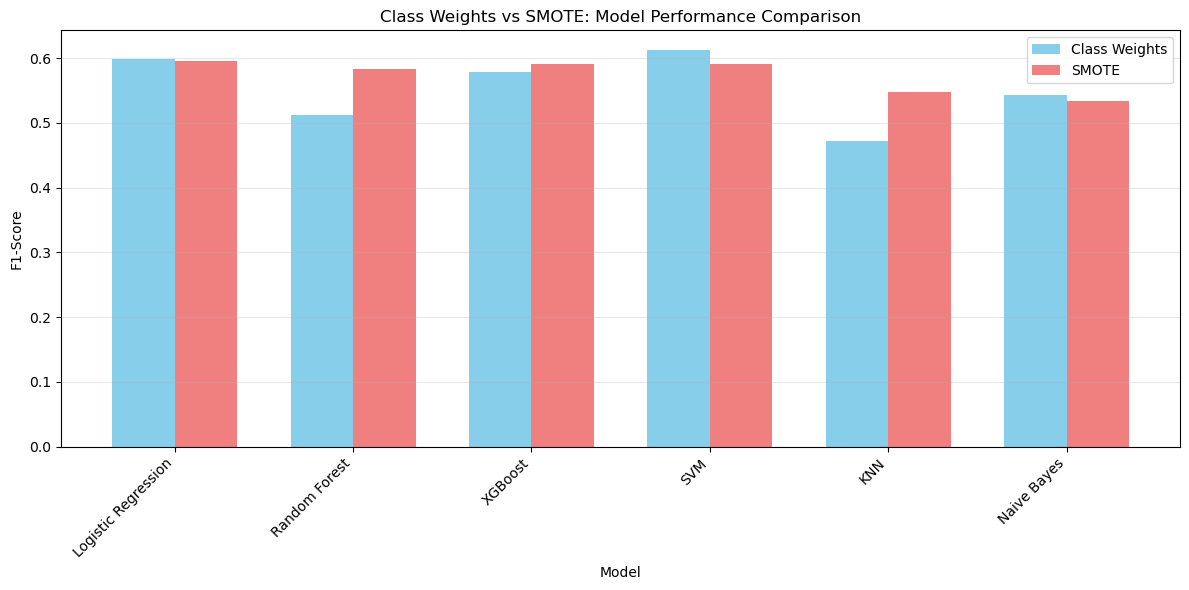


🏆 WINNER: SMOTE
   Average F1-Score: 0.5527 (Class Weights) vs 0.5735 (SMOTE)


In [265]:
# =============================================================================
# COMPARE: CLASS WEIGHTS vs SMOTE
# =============================================================================

print("\n" + "="*70)
print("TRAINING MODELS WITH SMOTE FOR COMPARISON")
print("="*70)

# Train same models with SMOTE data (without class weights)
models_smote = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results_smote = {}

for name, model in models_smote.items():
    print(f"\nTraining {name} with SMOTE...")
    
    # Train on SMOTE data
    model.fit(X_train_smote_scaled, y_train_smote)
    
    # Predict on same test set
    y_pred = model.predict(X_test_scaled) # ← Change to X_test_scaled
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    results_smote[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ✓ ROC-AUC:  {roc_auc:.4f}")

print("\n" + "="*70)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Class Weights F1': [results[m]['f1_score'] for m in results.keys()],
    'SMOTE F1': [results_smote[m]['f1_score'] for m in results_smote.keys()],
    'Difference': [results_smote[m]['f1_score'] - results[m]['f1_score'] for m in results.keys()]
})

print("\n📊 CLASS WEIGHTS vs SMOTE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Class Weights F1'], width, 
       label='Class Weights', color='skyblue')
ax.bar(x + width/2, comparison_df['SMOTE F1'], width, 
       label='SMOTE', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score')
ax.set_title('Class Weights vs SMOTE: Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determine winner
best_approach = "Class Weights" if comparison_df['Class Weights F1'].mean() > comparison_df['SMOTE F1'].mean() else "SMOTE"
print(f"\n🏆 WINNER: {best_approach}")
print(f"   Average F1-Score: {comparison_df['Class Weights F1'].mean():.4f} (Class Weights) vs {comparison_df['SMOTE F1'].mean():.4f} (SMOTE)")


CROSS-VALIDATION EVALUATION (5-Fold Stratified)

Evaluating Logistic Regression...
  Accuracy:  0.6986 (+/- 0.0130)
  F1-Score:  0.5886 (+/- 0.0157)
  ROC-AUC:   0.7811 (+/- 0.0115)
  Precision: 0.5014
  Recall:    0.7130

Evaluating Random Forest...
  Accuracy:  0.7414 (+/- 0.0104)
  F1-Score:  0.5053 (+/- 0.0239)
  ROC-AUC:   0.7739 (+/- 0.0113)
  Precision: 0.5992
  Recall:    0.4373
  ⚠️  Potential overfitting detected (gap: 0.2439)

Evaluating XGBoost...
  Accuracy:  0.7179 (+/- 0.0109)
  F1-Score:  0.5543 (+/- 0.0110)
  ROC-AUC:   0.7773 (+/- 0.0121)
  Precision: 0.5315
  Recall:    0.5799
  ⚠️  Potential overfitting detected (gap: 0.2474)

Evaluating SVM...
  Accuracy:  0.6841 (+/- 0.0099)
  F1-Score:  0.5923 (+/- 0.0123)
  ROC-AUC:   0.7715 (+/- 0.0094)
  Precision: 0.4858
  Recall:    0.7590

Evaluating KNN...
  Accuracy:  0.7140 (+/- 0.0049)
  F1-Score:  0.4605 (+/- 0.0180)
  ROC-AUC:   0.7080 (+/- 0.0120)
  Precision: 0.5357
  Recall:    0.4043

Evaluating Naive Bayes...
  

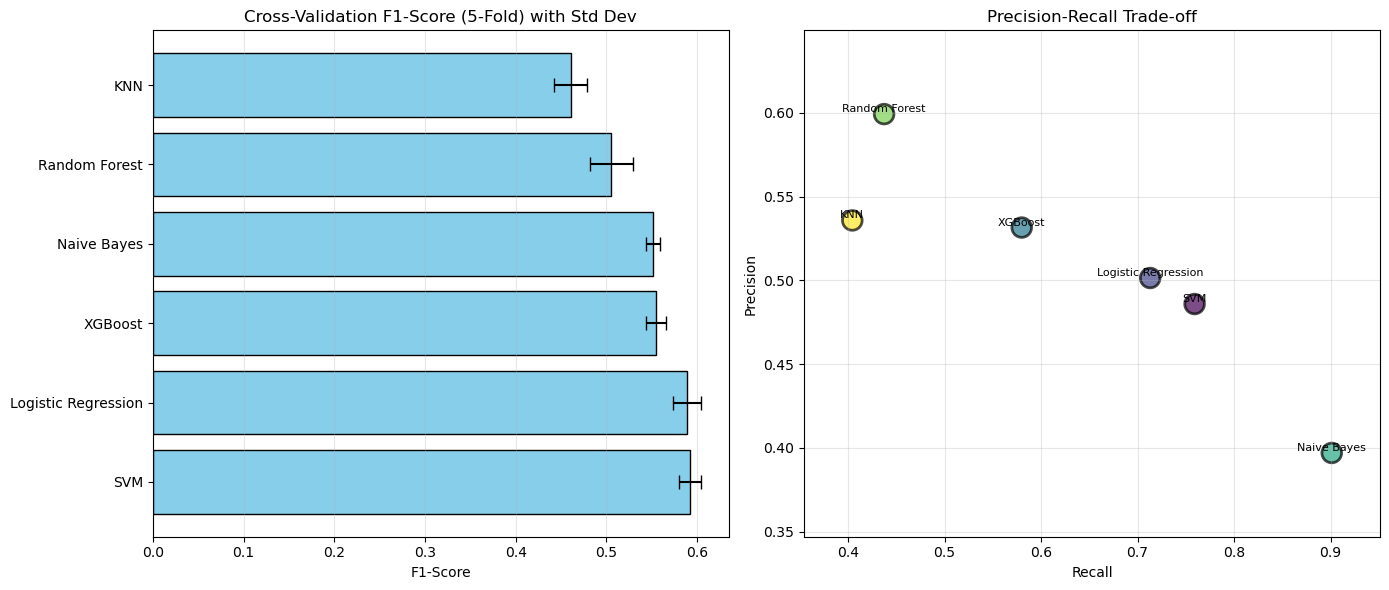


✓ Cross-validation completed. Top 3 models will undergo hyperparameter tuning.


In [266]:
# =============================================================================
# STEP 3: CROSS-VALIDATION FOR ROBUST EVALUATION
# =============================================================================

print("\n" + "="*70)
print("CROSS-VALIDATION EVALUATION (5-Fold Stratified)")
print("="*70)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Store cross-validation results
cv_results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Perform 5-fold stratified cross-validation
    cv_scores = cross_validate(
        model, 
        X_train_scaled, 
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Calculate mean and std for each metric
    cv_results[name] = {
        'accuracy_mean': cv_scores['test_accuracy'].mean(),
        'accuracy_std': cv_scores['test_accuracy'].std(),
        'f1_mean': cv_scores['test_f1'].mean(),
        'f1_std': cv_scores['test_f1'].std(),
        'roc_auc_mean': cv_scores['test_roc_auc'].mean(),
        'roc_auc_std': cv_scores['test_roc_auc'].std(),
        'precision_mean': cv_scores['test_precision'].mean(),
        'recall_mean': cv_scores['test_recall'].mean(),
        'train_accuracy': cv_scores['train_accuracy'].mean()
    }
    
    print(f"  Accuracy:  {cv_results[name]['accuracy_mean']:.4f} (+/- {cv_results[name]['accuracy_std']:.4f})")
    print(f"  F1-Score:  {cv_results[name]['f1_mean']:.4f} (+/- {cv_results[name]['f1_std']:.4f})")
    print(f"  ROC-AUC:   {cv_results[name]['roc_auc_mean']:.4f} (+/- {cv_results[name]['roc_auc_std']:.4f})")
    print(f"  Precision: {cv_results[name]['precision_mean']:.4f}")
    print(f"  Recall:    {cv_results[name]['recall_mean']:.4f}")
    
    # Check for overfitting
    overfit_gap = cv_results[name]['train_accuracy'] - cv_results[name]['accuracy_mean']
    if overfit_gap > 0.1:
        print(f"  ⚠️  Potential overfitting detected (gap: {overfit_gap:.4f})")

print("\n" + "="*70)

# Create CV results comparison
cv_comparison_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Accuracy': [cv_results[m]['accuracy_mean'] for m in cv_results.keys()],
    'F1-Score': [cv_results[m]['f1_mean'] for m in cv_results.keys()],
    'ROC-AUC': [cv_results[m]['roc_auc_mean'] for m in cv_results.keys()],
    'Precision': [cv_results[m]['precision_mean'] for m in cv_results.keys()],
    'Recall': [cv_results[m]['recall_mean'] for m in cv_results.keys()]
})

cv_comparison_df = cv_comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nCROSS-VALIDATION RESULTS SUMMARY")
print("="*70)
print(cv_comparison_df.to_string(index=False, float_format='%.4f'))
print("="*70)
# Visualize CV performance with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: F1-Score with standard deviation
models_sorted = cv_comparison_df['Model'].tolist()
f1_means = [cv_results[m]['f1_mean'] for m in models_sorted]
f1_stds = [cv_results[m]['f1_std'] for m in models_sorted]

axes[0].barh(models_sorted, f1_means, xerr=f1_stds, capsize=5, color='skyblue', edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Cross-Validation F1-Score (5-Fold) with Std Dev')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Precision-Recall Trade-off
precision = [cv_results[m]['precision_mean'] for m in models_sorted]
recall = [cv_results[m]['recall_mean'] for m in models_sorted]

axes[1].scatter(recall, precision, s=200, c=range(len(models_sorted)), 
                cmap='viridis', edgecolors='black', linewidths=2, alpha=0.7)

for i, model in enumerate(models_sorted):
    axes[1].annotate(model, (recall[i], precision[i]), 
                    fontsize=8, ha='center', va='bottom')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off')
axes[1].grid(alpha=0.3)
axes[1].set_xlim([min(recall) - 0.05, max(recall) + 0.05])
axes[1].set_ylim([min(precision) - 0.05, max(precision) + 0.05])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"✓ Cross-validation completed. Top 3 models will undergo hyperparameter tuning.")
print("="*70)

In [267]:
# # =============================================================================
# # STEP 3.5: FEATURE SELECTION WITH PERFORMANCE COMPARISON
# # =============================================================================

# print("\n" + "="*70)
# print("FEATURE SELECTION - PERFORMANCE-BASED")
# print("="*70)

# # Get best model from CV
# best_model_name = cv_comparison_df.iloc[0]['Model']
# best_model = models[best_model_name]

# print(f"\nUsing {best_model_name} for feature selection...")

# # Train on full training set
# best_model.fit(X_train_scaled, y_train)

# # Get feature importance
# if hasattr(best_model, 'feature_importances_'):
#     importances = best_model.feature_importances_
# elif hasattr(best_model, 'coef_'):
#     importances = np.abs(best_model.coef_[0])
# else:
#     # Use permutation importance
#     from sklearn.inspection import permutation_importance
#     perm_result = permutation_importance(
#         best_model, X_train_scaled, y_train,
#         n_repeats=10, random_state=42, scoring='f1'
#     )
#     importances = perm_result.importances_mean

# # Create importance DataFrame
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': importances
# }).sort_values('Importance', ascending=False)

# print("\nFeature Importance Ranking:")
# print(feature_importance_df.to_string(index=False))

# # Test different feature counts
# print("\n" + "="*70)
# print("TESTING DIFFERENT FEATURE COUNTS")
# print("="*70)

# results_by_k = []

# for k in [10, 12, 15, 18, 20, 23]:  # Test different numbers
#     # Select top k features
#     top_k_features = feature_importance_df.head(k)['Feature'].tolist()
    
#     # Get indices
#     feature_indices = [feature_columns.index(f) for f in top_k_features]
    
#     # Train with selected features
#     X_train_k = X_train_scaled[:, feature_indices]
#     X_test_k = X_test_scaled[:, feature_indices]
    
#     # Re-initialize model
#     if best_model_name == 'XGBoost':
#         model_k = XGBClassifier(
#             scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])),
#             random_state=42, eval_metric='logloss'
#         )
#     elif best_model_name == 'Random Forest':
#         model_k = RandomForestClassifier(
#             class_weight='balanced', random_state=42, n_estimators=100
#         )
#     else:
#         model_k = best_model
    
#     model_k.fit(X_train_k, y_train)
#     y_pred_k = model_k.predict(X_test_k)
    
#     f1_k = f1_score(y_test, y_pred_k, pos_label=1)
#     acc_k = accuracy_score(y_test, y_pred_k)
    
#     results_by_k.append({
#         'Num_Features': k,
#         'F1_Score': f1_k,
#         'Accuracy': acc_k,
#         'Features': top_k_features
#     })
    
#     print(f"\nTop {k} features: F1={f1_k:.4f}, Acc={acc_k:.4f}")

# # Visualize
# results_df = pd.DataFrame(results_by_k)

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(results_df['Num_Features'], results_df['F1_Score'], 'o-', linewidth=2, markersize=8, label='F1-Score')
# ax.plot(results_df['Num_Features'], results_df['Accuracy'], 's-', linewidth=2, markersize=8, label='Accuracy')
# ax.axhline(y=results[best_model_name]['f1_score'], color='red', linestyle='--', label='Baseline F1 (all features)')
# ax.set_xlabel('Number of Features')
# ax.set_ylabel('Score')
# ax.set_title(f'Feature Selection Impact - {best_model_name}')
# ax.legend()
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Find optimal k
# best_k_idx = results_df['F1_Score'].idxmax()
# best_k = results_df.loc[best_k_idx, 'Num_Features']
# best_f1 = results_df.loc[best_k_idx, 'F1_Score']

# print("\n" + "="*70)
# print("RECOMMENDATION")
# print("="*70)
# print(f"\n🎯 Optimal number of features: {best_k}")
# print(f"   F1-Score: {best_f1:.4f}")
# print(f"   Baseline: {results[best_model_name]['f1_score']:.4f}")
# print(f"   Change:   {best_f1 - results[best_model_name]['f1_score']:+.4f}")

# if best_f1 >= results[best_model_name]['f1_score'] - 0.01:
#     print(f"\n✅ Use {best_k} features (similar/better performance, simpler model)")
# else:
#     print(f"\n⚠️  Keep all {len(feature_columns)} features (better performance)")

# print("="*70)

In [268]:
# # =============================================================================
# # STEP 3.6: APPLY FEATURE SELECTION DECISION & PREPARE FOR TUNING
# # =============================================================================

# print("\n" + "="*70)
# print("FINALIZING FEATURES FOR HYPERPARAMETER TUNING")
# print("="*70)

# # Decision threshold (allow 1% F1 drop for simpler model)
# threshold = -0.01
# improvement = best_f1 - results[best_model_name]['f1_score']

# if improvement >= threshold:
#     # USE SELECTED FEATURES
#     print(f"\n✅ Using {best_k} selected features")
#     print(f"   F1 change: {improvement:+.4f} (within acceptable range)")
    
#     selected_features = results_by_k[best_k_idx]['Features']
#     feature_indices = [feature_columns.index(f) for f in selected_features]
    
#     # Update training/test sets
#     X_train_scaled = X_train_scaled[:, feature_indices]
#     X_test_scaled = X_test_scaled[:, feature_indices]
    
#     # Save selected features for documentation
#     print("\n📋 Selected Features:")
#     for i, feat in enumerate(selected_features, 1):
#         imp = feature_importance_df[feature_importance_df['Feature'] == feat]['Importance'].values[0]
#         print(f"   {i:2d}. {feat:25s} (importance: {imp:.4f})")
    
# else:
#     # KEEP ALL FEATURES
#     print(f"\n⚠️  Keeping all {len(feature_columns)} features")
#     print(f"   F1 change: {improvement:.4f} (too large to sacrifice)")
#     selected_features = feature_columns.copy()

# # Store for final report
# final_features = selected_features
# final_feature_count = len(selected_features)

# print(f"\n✓ Feature set finalized: {final_feature_count} features")
# print(f"   Training shape: {X_train_scaled.shape}")
# print(f"   Test shape:     {X_test_scaled.shape}")
# print("="*70)

# # NOW PROCEED TO STEP 4: HYPERPARAMETER TUNING
# # (Your existing STEP 4 code remains unchanged, just uses the updated X_train_scaled/X_test_scaled)

In [269]:
# =============================================================================
# STEP 4: HYPERPARAMETER TUNING FOR TOP 3 MODELS
# =============================================================================

# Select top 3 models based on CV F1-score
top_3_models = cv_comparison_df.head(3)['Model'].tolist()

print("\n" + "="*70)
print(f"HYPERPARAMETER TUNING - TOP 3 MODELS")
print("="*70)
print(f"Selected models: {', '.join(top_3_models)}")
print("="*70)

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

# Store tuned models
tuned_models = {}
tuning_results = {}

for model_name in top_3_models:
    print(f"\n{'='*70}")
    print(f"Tuning {model_name}...")
    print('='*70)
    
    # Get base model
    if model_name == 'Logistic Regression':
        base_model = LogisticRegression(class_weight='balanced', random_state=42)
    elif model_name == 'Random Forest':
        base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(
            scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])),
            random_state=42,
            eval_metric='logloss'
        )
    elif model_name == 'SVM':
        base_model = SVC(class_weight='balanced', random_state=42, probability=True)
    elif model_name == 'KNN':
        base_model = KNeighborsClassifier()
    elif model_name == 'Naive Bayes':
        base_model = GaussianNB()
    
    # Grid search with stratified k-fold
    grid_search = GridSearchCV(
        base_model,
        param_grids[model_name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Store results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }
    
    print(f"\n✓ Best parameters found:")
    for param, value in grid_search.best_params_.items():
        print(f"    {param}: {value}")
    print(f"\n✓ Best CV F1-Score: {grid_search.best_score_:.4f}")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING COMPLETED")
print("="*70)


print("\n📊 TUNING SUMMARY")
print("="*70)

tuning_summary = pd.DataFrame({
    'Model': list(tuning_results.keys()),
    'Best CV F1': [tuning_results[m]['best_score'] for m in tuning_results.keys()],
    'Baseline CV F1': [cv_results[m]['f1_mean'] for m in tuning_results.keys()],
    'Improvement': [tuning_results[m]['best_score'] - cv_results[m]['f1_mean'] 
                    for m in tuning_results.keys()]
})

print(tuning_summary.to_string(index=False, float_format='%.4f'))
print("="*70)


HYPERPARAMETER TUNING - TOP 3 MODELS
Selected models: SVM, Logistic Regression, XGBoost

Tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Best parameters found:
    C: 1
    gamma: scale
    kernel: linear

✓ Best CV F1-Score: 0.5965

Tuning Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Best parameters found:
    C: 1
    max_iter: 1000
    penalty: l1
    solver: saga

✓ Best CV F1-Score: 0.5888

Tuning XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✓ Best parameters found:
    colsample_bytree: 0.9
    learning_rate: 0.05
    max_depth: 3
    n_estimators: 300
    subsample: 1.0

✓ Best CV F1-Score: 0.6201

HYPERPARAMETER TUNING COMPLETED

📊 TUNING SUMMARY
              Model  Best CV F1  Baseline CV F1  Improvement
                SVM      0.5965          0.5923       0.0042
Logistic Regression      0.5888          0.5886       0.0002
            XGBoost      0.6201          0.5543 


TUNED MODELS EVALUATION ON TEST SET

SVM:
  Accuracy:  0.6896
  F1-Score:  0.5330
  ROC-AUC:   0.7851

Logistic Regression:
  Accuracy:  0.6956
  F1-Score:  0.5330
  ROC-AUC:   0.7881

XGBoost:
  Accuracy:  0.6983
  F1-Score:  0.5330
  ROC-AUC:   0.7993


IMPROVEMENT AFTER TUNING
              Model  Before F1  After F1  Improvement
                SVM     0.6122    0.5330      -0.0792
Logistic Regression     0.5980    0.5330      -0.0650
            XGBoost     0.5793    0.5330      -0.0463


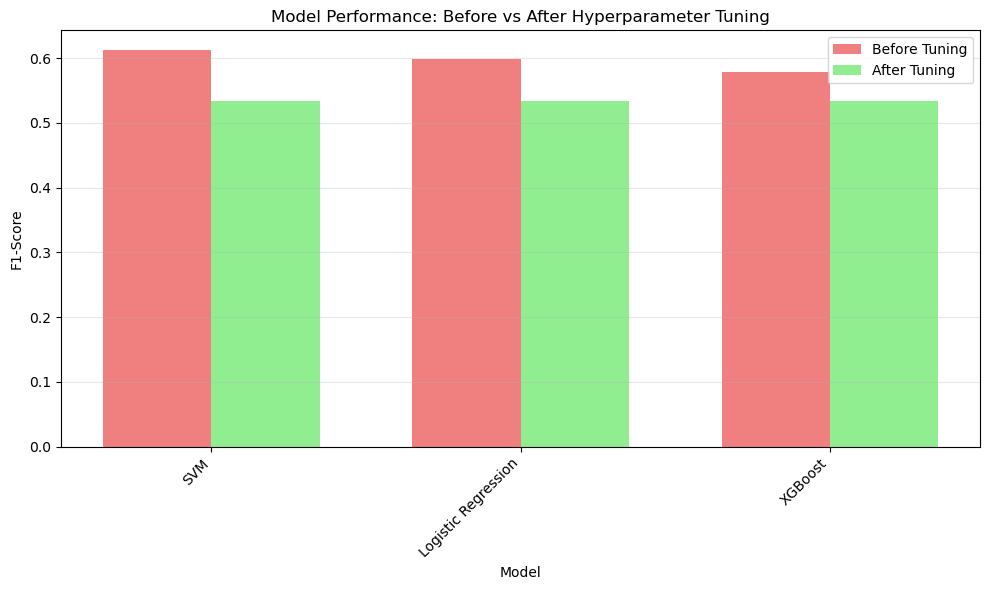

In [270]:
# =============================================================================
# STEP 5: EVALUATE TUNED MODELS ON TEST SET
# =============================================================================

print("\n" + "="*70)
print("TUNED MODELS EVALUATION ON TEST SET")
print("="*70)

tuned_results = {}

for model_name, model in tuned_models.items():
    print(f"\n{model_name}:")
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    ff1 = f1_score(y_test, y_pred, pos_label=1)  # ✓ Add this
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    tuned_results[model_name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'model': model
    }
    
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\n" + "="*70)

# Compare Before vs After Tuning
print("\nIMPROVEMENT AFTER TUNING")
print("="*70)

improvement_df = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'Before F1': [results[m]['f1_score'] for m in tuned_results.keys()],
    'After F1': [tuned_results[m]['f1_score'] for m in tuned_results.keys()],
    'Improvement': [tuned_results[m]['f1_score'] - results[m]['f1_score'] 
                   for m in tuned_results.keys()]
})

print(improvement_df.to_string(index=False, float_format='%.4f'))
print("="*70)

# Visualize improvement
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(improvement_df))
width = 0.35

ax.bar(x - width/2, improvement_df['Before F1'], width, label='Before Tuning', color='lightcoral')
ax.bar(x + width/2, improvement_df['After F1'], width, label='After Tuning', color='lightgreen')

ax.set_xlabel('Model')
ax.set_ylabel('F1-Score')
ax.set_title('Model Performance: Before vs After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(improvement_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


FINAL BEST MODEL: SVM

Best Hyperparameters:
  C: 1
  gamma: scale
  kernel: linear

Performance Metrics:
  Accuracy:  0.6896
  F1-Score:  0.5330
  ROC-AUC:   0.7851

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.86      0.66      0.75      1279
     Popular       0.49      0.76      0.60       554

    accuracy                           0.69      1833
   macro avg       0.68      0.71      0.67      1833
weighted avg       0.75      0.69      0.70      1833



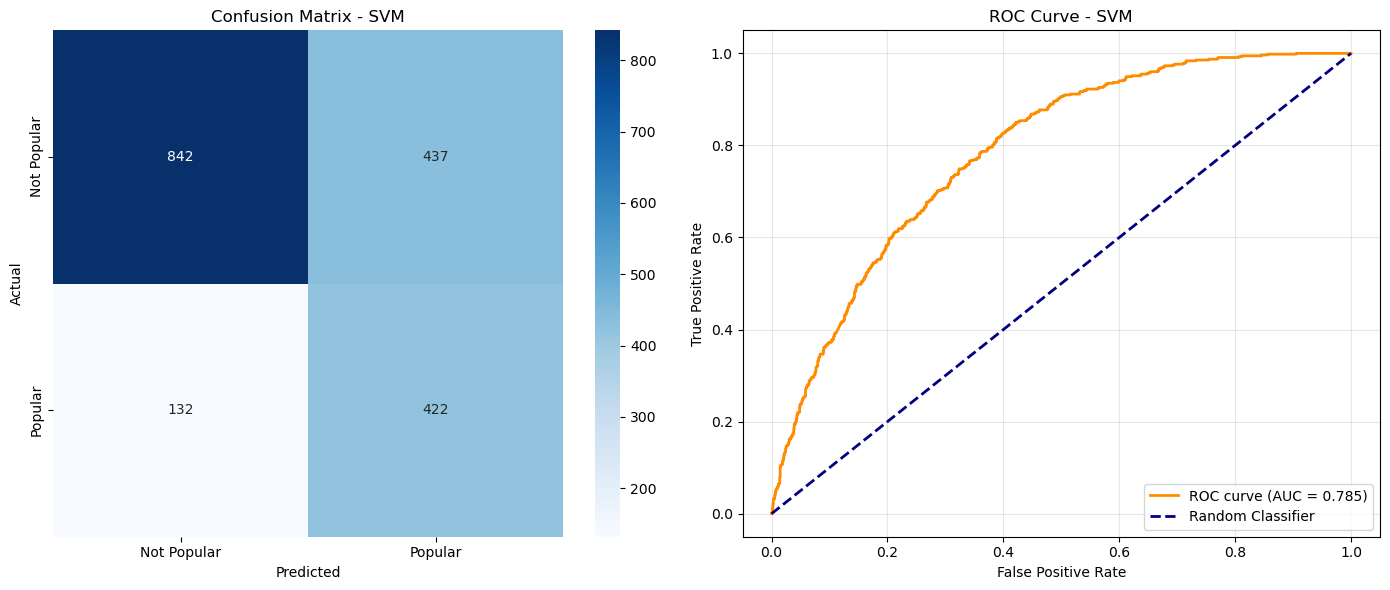

In [271]:
# =============================================================================
# FINAL BEST MODEL SELECTION AND DETAILED EVALUATION
# =============================================================================

# Select best tuned model
best_tuned_model_name = max(tuned_results.items(), key=lambda x: x[1]['f1_score'])[0]
best_tuned_model = tuned_results[best_tuned_model_name]

print("\n" + "="*70)
print(f"FINAL BEST MODEL: {best_tuned_model_name}")
print("="*70)

print("\nBest Hyperparameters:")
for param, value in tuning_results[best_tuned_model_name]['best_params'].items():
    print(f"  {param}: {value}")

print("\nPerformance Metrics:")
print(f"  Accuracy:  {best_tuned_model['accuracy']:.4f}")
print(f"  F1-Score:  {best_tuned_model['f1_score']:.4f}")
print(f"  ROC-AUC:   {best_tuned_model['roc_auc']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_tuned_model['predictions'],
                          target_names=['Not Popular', 'Popular']))

# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, best_tuned_model['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_tuned_model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_tuned_model['probabilities'])
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {best_tuned_model["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
            label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_tuned_model_name}')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("="*70)

In [272]:
# =============================================================================
# FINAL SUMMARY: COMPLETE MODEL DEVELOPMENT PIPELINE
# =============================================================================

print("\n" + "="*70)
print("🎯 FINAL MODEL DEVELOPMENT SUMMARY")
print("="*70)

print("\n📊 DATASET")
print("-" * 70)
print(f"Total songs:        {len(df_enhanced):,}")
print(f"Training samples:   {len(y_train):,}")
print(f"Test samples:       {len(y_test):,}")
print(f"Class imbalance:    {imbalance_ratio:.2f}:1")

print("\n🔧 FEATURE ENGINEERING")
print("-" * 70)
# print(f"Original features:  {len(feature_columns)}")
# print(f"Selected features:  {final_feature_count}")
# print(f"Reduction:          {len(feature_columns) - final_feature_count} features removed")
print(f"✓ Using all {final_feature_count} features (no feature selection applied)")

print("\n🏆 BEST MODEL")
print("-" * 70)
print(f"Model:              {best_tuned_model_name}")
print(f"F1-Score:           {best_tuned_model['f1_score']:.4f}")
print(f"Accuracy:           {best_tuned_model['accuracy']:.4f}")
print(f"ROC-AUC:            {best_tuned_model['roc_auc']:.4f}")

print("\n📈 PERFORMANCE IMPROVEMENTS")
print("-" * 70)
print(f"Baseline F1:        {results[best_tuned_model_name]['f1_score']:.4f}")
print(f"After Tuning:       {best_tuned_model['f1_score']:.4f}")
print(f"Total Improvement:  {best_tuned_model['f1_score'] - results[best_tuned_model_name]['f1_score']:+.4f}")

print("\n⚙️  BEST HYPERPARAMETERS")
print("-" * 70)
for param, value in tuning_results[best_tuned_model_name]['best_params'].items():
    print(f"{param:25s}: {value}")

print("\n✅ MODEL READY FOR DEPLOYMENT")
print("="*70)


🎯 FINAL MODEL DEVELOPMENT SUMMARY

📊 DATASET
----------------------------------------------------------------------
Total songs:        9,161
Training samples:   7,328
Test samples:       1,833
Class imbalance:    2.31:1

🔧 FEATURE ENGINEERING
----------------------------------------------------------------------
✓ Using all 15 features (no feature selection applied)

🏆 BEST MODEL
----------------------------------------------------------------------
Model:              SVM
F1-Score:           0.5330
Accuracy:           0.6896
ROC-AUC:            0.7851

📈 PERFORMANCE IMPROVEMENTS
----------------------------------------------------------------------
Baseline F1:        0.6122
After Tuning:       0.5330
Total Improvement:  -0.0792

⚙️  BEST HYPERPARAMETERS
----------------------------------------------------------------------
C                        : 1
gamma                    : scale
kernel                   : linear

✅ MODEL READY FOR DEPLOYMENT


In [273]:
# =============================================================================
# SAVE FINAL MODEL
# =============================================================================

import joblib
from datetime import datetime

# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'best_model_{best_tuned_model_name.replace(" ", "_")}_{timestamp}.pkl'

joblib.dump({
    'model': best_tuned_model['model'],
    'scaler': scaler,
    'feature_columns': feature_columns,
    'label_encoder': label_encoder,
    'best_params': tuning_results[best_tuned_model_name]['best_params'],
    'performance': {
        'f1_score': best_tuned_model['f1_score'],
        'accuracy': best_tuned_model['accuracy'],
        'roc_auc': best_tuned_model['roc_auc']
    }
}, model_filename)

print(f"\n✅ Model saved to: {model_filename}")


✅ Model saved to: best_model_SVM_20251026_122731.pkl
